# 산학프로젝트
**제조 공정 품질 불량 예측**

# 03 Baseline Modeling

- 기준선 확보 (스크리닝)
- 입력 데이터: `labeled_modeling.csv` (보정·중복 제거·CN7·RG3 한정 완료)
- 평가 프로토콜: 80/20 단일 분할 (`random_state=0`), test set 1046건 / 불량 12건
- 주의: 여기 수치는 **후보 비교용**임. 보고 수치는 **04_6 반복 CV 기준**

## import

In [1]:
import pandas as pd
import numpy as np
import os

## 경로설정

In [2]:
os.chdir("data")

## 데이터 불러오기

In [3]:
# 02_EDA에서 저장한 전처리 데이터
# - 기록 오류 보정, 중복 제거, CN7·RG3 한정, PassOrFail 인코딩(양품 0 / 불량 1), Part 파생까지 끝난 상태
model_data=pd.read_csv('labeled_modeling.csv', index_col=0)

print(f'{model_data.shape[0]}행 {model_data.shape[1]}컬럼 / 불량 {int(model_data["PassOrFail"].sum())}건')

5230행 30컬럼 / 불량 60건


In [4]:
model_data.head()

,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,...,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,Part
0,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,0,9.59,4.47,16.92,59.520000,...,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,66.300003,24.799999,27.5,CN7RH
1,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,0,9.60,4.48,16.91,59.580002,...,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6,CN7RH
2,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,0,9.60,4.48,16.91,59.580002,...,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6,CN7LH
3,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,0,9.59,4.48,16.91,59.560001,...,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6,CN7LH
4,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,0,9.59,4.48,16.91,59.560001,...,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6,CN7RH


## 데이터 전처리

In [5]:
def info_df(df):
    info=pd.DataFrame(
        {
            "Columns": df.columns,
            "Non-Null Count": df.notna().sum().values,
            "Dtype": df.dtypes.values
        }
    )
    return info

In [6]:
info_df(model_data)

,Columns,Non-Null Count,Dtype
0,TimeStamp,5230,str
1,PART_FACT_PLAN_DATE,5230,str
2,PART_FACT_SERIAL,5230,int64
3,PART_NAME,5230,str
4,EQUIP_CD,5230,str
5,PassOrFail,5230,int64
6,Injection_Time,5230,float64
7,Filling_Time,5230,float64
8,Plasticizing_Time,5230,float64
9,Cycle_Time,5230,float64


### 식별 컬럼 제외

- 모델 입력에 쓰지 않는 **식별 컬럼만** 제거. 고정값·라벨 누수 컬럼은 **02_EDA에서 이미 제외**
- `Part`는 03에서 미사용, **04_1부터 더미변수로 투입**

In [7]:
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD', 'Part']

final_df=model_data.drop(columns=drop_columns)
final_df.shape

(5230, 24)

In [8]:
final_df.head()

,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Max_Injection_Speed,Max_Screw_RPM,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,9.59,4.47,16.92,59.520000,7.13,653.409973,68.849998,55.400002,30.700001,...,37.400002,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,66.300003,24.799999,27.5
1,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,55.299999,30.799999,...,37.500000,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
2,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,55.299999,30.799999,...,37.500000,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
3,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,55.299999,31.000000,...,37.500000,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6
4,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,55.299999,31.000000,...,37.500000,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6


### 데이터 분할

In [9]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(final_df.drop(columns='PassOrFail'), final_df['PassOrFail'], test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(4184, 23) (4184,)
(1046, 23) (1046,)


### 데이터 스케일링

In [10]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

## 모델링

### Base Model

In [11]:
model_dict={}

In [12]:
from sklearn import set_config
set_config(display='text')

# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=1000, random_state=0)
rf.fit(x_train_scaled, y_train)
model_dict['RandomForest']=rf

# Bagging
from sklearn.ensemble import BaggingClassifier

bag=BaggingClassifier(n_estimators=1000, random_state=0)
bag.fit(x_train_scaled, y_train)
model_dict['Bagging']=bag

# XGBoost
from xgboost import XGBClassifier

xgb=XGBClassifier(n_estimators=1000, random_state=0)
xgb.fit(x_train_scaled, y_train)
model_dict['XGBoost']=xgb

In [13]:
result_df=pd.DataFrame(columns=['Model', 'Defect Precision', 'Defect Recall', 'Defect F1 Score', 'Average Precision'])

RandomForest
Accuracy: 0.9818355640535373
Average Precision: 0.44424987767132273
Classification Report
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.29      0.42      0.34        12

    accuracy                           0.98      1046
   macro avg       0.64      0.70      0.67      1046
weighted avg       0.99      0.98      0.98      1046



Bagging
Accuracy: 0.9837476099426387
Average Precision: 0.4419109369550902
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.37      0.58      0.45        12

    accuracy                           0.98      1046
   macro avg       0.68      0.79      0.72      1046
weighted avg       0.99      0.98      0.99      1046

XGBoost
Accuracy: 0.9837476099426387
Average Precision: 0.27014433110850733
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.37      0.58      0.45        12

    accuracy                           0.98      1046
   macro avg       0.68      0.79      0.72      1046
weighted avg       0.99      0.98      0.99      1046



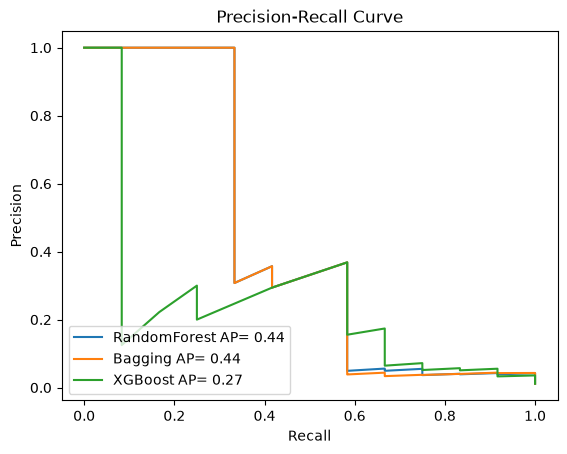

In [14]:
# 저장한 학습 모델 불러와서 예측
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report
plt.figure()
for model in model_dict:
    x_pred=model_dict[model].predict(x_test_scaled)
    y_prob=model_dict[model].predict_proba(x_test_scaled)
    acc=model_dict[model].score(x_test_scaled, y_test)
    ap_score=average_precision_score(y_test, y_prob[:, 1])
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob[:, 1])

    print("=" * 80)
    print(model)
    print("=" * 80)
    print(f'Accuracy: {acc}')
    print(f'Average Precision: {ap_score}')
    print("Classification Report")
    print(classification_report(y_test, x_pred, target_names=['양품', '불량']))
    plt.plot(recall, precision, label=f'{model} AP= {ap_score:.2f}')

    report=classification_report(y_test, x_pred, target_names=['양품', '불량'], output_dict=True)
    precision_defect=report['불량']['precision']
    recall_defect=report['불량']['recall']
    f1_defect=report['불량']['f1-score']
    result_dict={'Model': f'{model} Baseline', 'Defect Precision': precision_defect, 'Defect Recall': recall_defect,
              'Defect F1 Score': f1_defect, 'Average Precision': ap_score}
    df=pd.DataFrame([result_dict])
    result_df=pd.concat([result_df, df], ignore_index=True)


plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

In [15]:
importance_df=pd.DataFrame({'Feature':x_train.columns, 'Importance':model_dict['RandomForest'].feature_importances_}).sort_values('Importance', ascending=False)
importance_df

,Feature,Importance
5,Cushion_Position,0.062797
14,Barrel_Temperature_1,0.057599
11,Max_Switch_Over_Pressure,0.055880
7,Max_Injection_Speed,0.055697
17,Barrel_Temperature_4,0.054375
20,Hopper_Temperature,0.053939
22,Mold_Temperature_4,0.051782
10,Max_Injection_Pressure,0.047147
2,Plasticizing_Time,0.046952
12,Max_Back_Pressure,0.046544


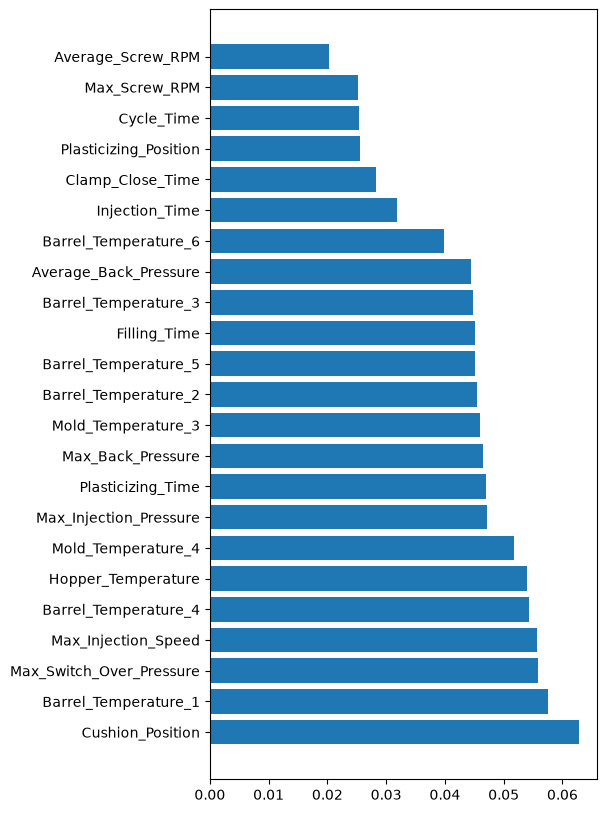

In [16]:
plt.figure(figsize=(5, 10))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.show()

In [17]:
result_df

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.44425
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144


In [18]:
result_df.to_csv('03_Baseline_Modeling_Result.csv', index=False)